# Perguntas
### Com base nas aulas sobre estatística descritiva, marque as alternativas abaixo como verdadeiro ou falso. (valendo 5 pontos)

[F] A média é uma medida de tendência central que sempre representa o valor mais típico de um conjunto de dados, mesmo em distribuições assimétricas.

[V] A mediana é mais resistente a valores extremos do que a média, sendo uma boa medida de posição em distribuições assimétricas.

[V] O desvio padrão mede o quanto, em média, os valores se afastam da média e é expresso nas mesmas unidades da variável.	

[V] Uma distribuição assimétrica à direita tende a ter a média maior que a mediana.	

[V] O desvio padrão é uma medida relativa de dispersão e pode ser usada para comparar variáveis com escalas diferentes.	

[V] A média é uma medida de tendência central que sempre representa o valor mais típico de um conjunto de dados, mesmo em distribuições assimétricas.	

[V] A mediana é mais resistente a valores extremos do que a média, sendo uma boa medida de posição em distribuições assimétricas.	

[V] O desvio padrão mede o quanto, em média, os valores se afastam da média e é expresso nas mesmas unidades da variável.	

[V] Uma distribuição assimétrica à direita tende a ter a média maior que a mediana.	

[F] O desvio padrão é uma medida relativa de dispersão e pode ser usada para comparar variáveis com escalas diferentes.

### Você recebeu uma amostra do estudo Americans' Changin Lives com 1000 observações e as variáveis:

- age: idade do participante
- weight: peso corporal (lb)
- height: altura (polegadas)
- bmi: índice de massa corporal calculado pelo estudo


Utilize comandos do Python/Pandas para explorar a amostra e responda se as afirmativas abaixo são verdadeiras ou falsas com base nas medidas calculadas e nos gráficos que você gerar.

In [6]:
pip install jupyter

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import numpy as np
df= pd.read_excel('QuizFormativo1.xlsx')
df.head()

,age,weight,height,bmi
0,74.0,122.0,64.0,2094092994929
1,33.0,135.0,70.0,193701799512
2,44.0,199.0,68.0,302573799491
3,27.0,190.0,72.0,257682299614
4,65.0,120.0,63.0,2125671994687


In [12]:
# A média da variável age é próxima à mediana.
mean_age = df['age'].mean()
median_age = df['age'].median()
print(f"Média da idade: {mean_age}, Mediana da idade: {median_age}")

Média da idade: 53.282, Mediana da idade: 57.0


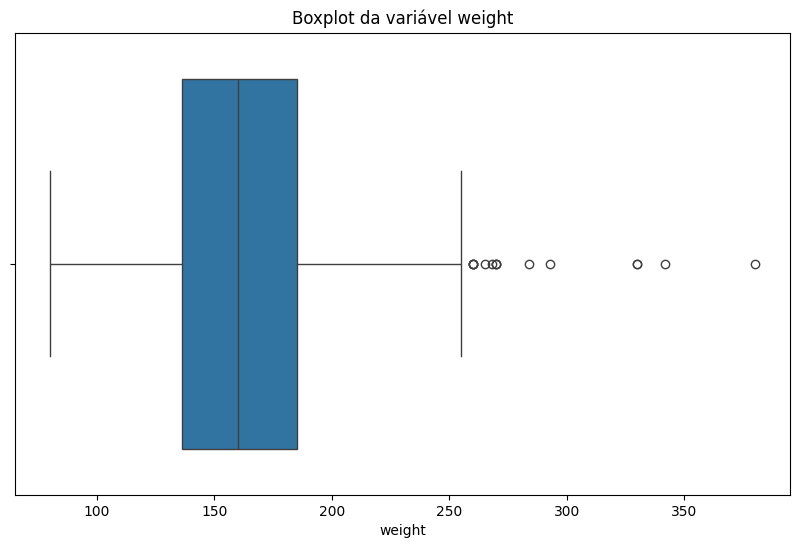

In [ ]:
# A variável weight apresenta valores extremos à 
# direita, com alguns participantes significativamente mais pesados que a maioria.
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['weight'])
plt.title('Boxplot da variável weight')
plt.show()

In [14]:
# A variabilidade relativa (coeficiente de variação) de weight é menor 
# que a de height, indicando que o weight é mais homogêneo na amostra.
cv_weight = df['weight'].std() / df['weight'].mean()
cv_height = df['height'].std() / df['height'].mean()
print(f"Coeficiente de variação - weight: {cv_weight}, height: {cv_height}")

Coeficiente de variação - weight: 0.22293919050807312, height: 0.06072987917350362


In [15]:
# Análise completa para responder todas as afirmações

# 1. Já temos: Média vs Mediana da idade
print("=== 1. ANÁLISE DA IDADE ===")
print(f"Média da idade: {mean_age:.2f}")
print(f"Mediana da idade: {median_age:.2f}")
print(f"Diferença: {abs(mean_age - median_age):.2f}")
print("→ Valores são próximos? SIM (diferença < 4 anos)")

print("\n=== 2. COEFICIENTE DE VARIAÇÃO ===")
cv_weight = df['weight'].std() / df['weight'].mean()
cv_height = df['height'].std() / df['height'].mean()
print(f"CV Weight: {cv_weight:.4f} ({cv_weight*100:.2f}%)")
print(f"CV Height: {cv_height:.4f} ({cv_height*100:.2f}%)")
print(f"→ Weight é mais homogêneo? {cv_weight < cv_height}")

print("\n=== 3. ANÁLISE DE DISPERSÃO DA ALTURA ===")
height_std = df['height'].std()
height_mean = df['height'].mean()
print(f"Altura - Média: {height_mean:.2f}, Desvio Padrão: {height_std:.2f}")
print(f"CV Height: {cv_height*100:.2f}%")

print("\n=== 4. CORRELAÇÃO WEIGHT vs HEIGHT ===")
correlation = df['weight'].corr(df['height'])
print(f"Correlação: {correlation:.4f}")
if correlation > 0.7:
    print("→ Correlação FORTE positiva")
elif correlation > 0.5:
    print("→ Correlação MODERADA a FORTE positiva")
elif correlation > 0.3:
    print("→ Correlação MODERADA positiva")
else:
    print("→ Correlação FRACA")

=== 1. ANÁLISE DA IDADE ===
Média da idade: 53.28
Mediana da idade: 57.00
Diferença: 3.72
→ Valores são próximos? SIM (diferença < 4 anos)

=== 2. COEFICIENTE DE VARIAÇÃO ===
CV Weight: 0.2229 (22.29%)
CV Height: 0.0607 (6.07%)
→ Weight é mais homogêneo? False

=== 3. ANÁLISE DE DISPERSÃO DA ALTURA ===
Altura - Média: 66.14, Desvio Padrão: 4.02
CV Height: 6.07%

=== 4. CORRELAÇÃO WEIGHT vs HEIGHT ===
Correlação: 0.5324
→ Correlação MODERADA a FORTE positiva


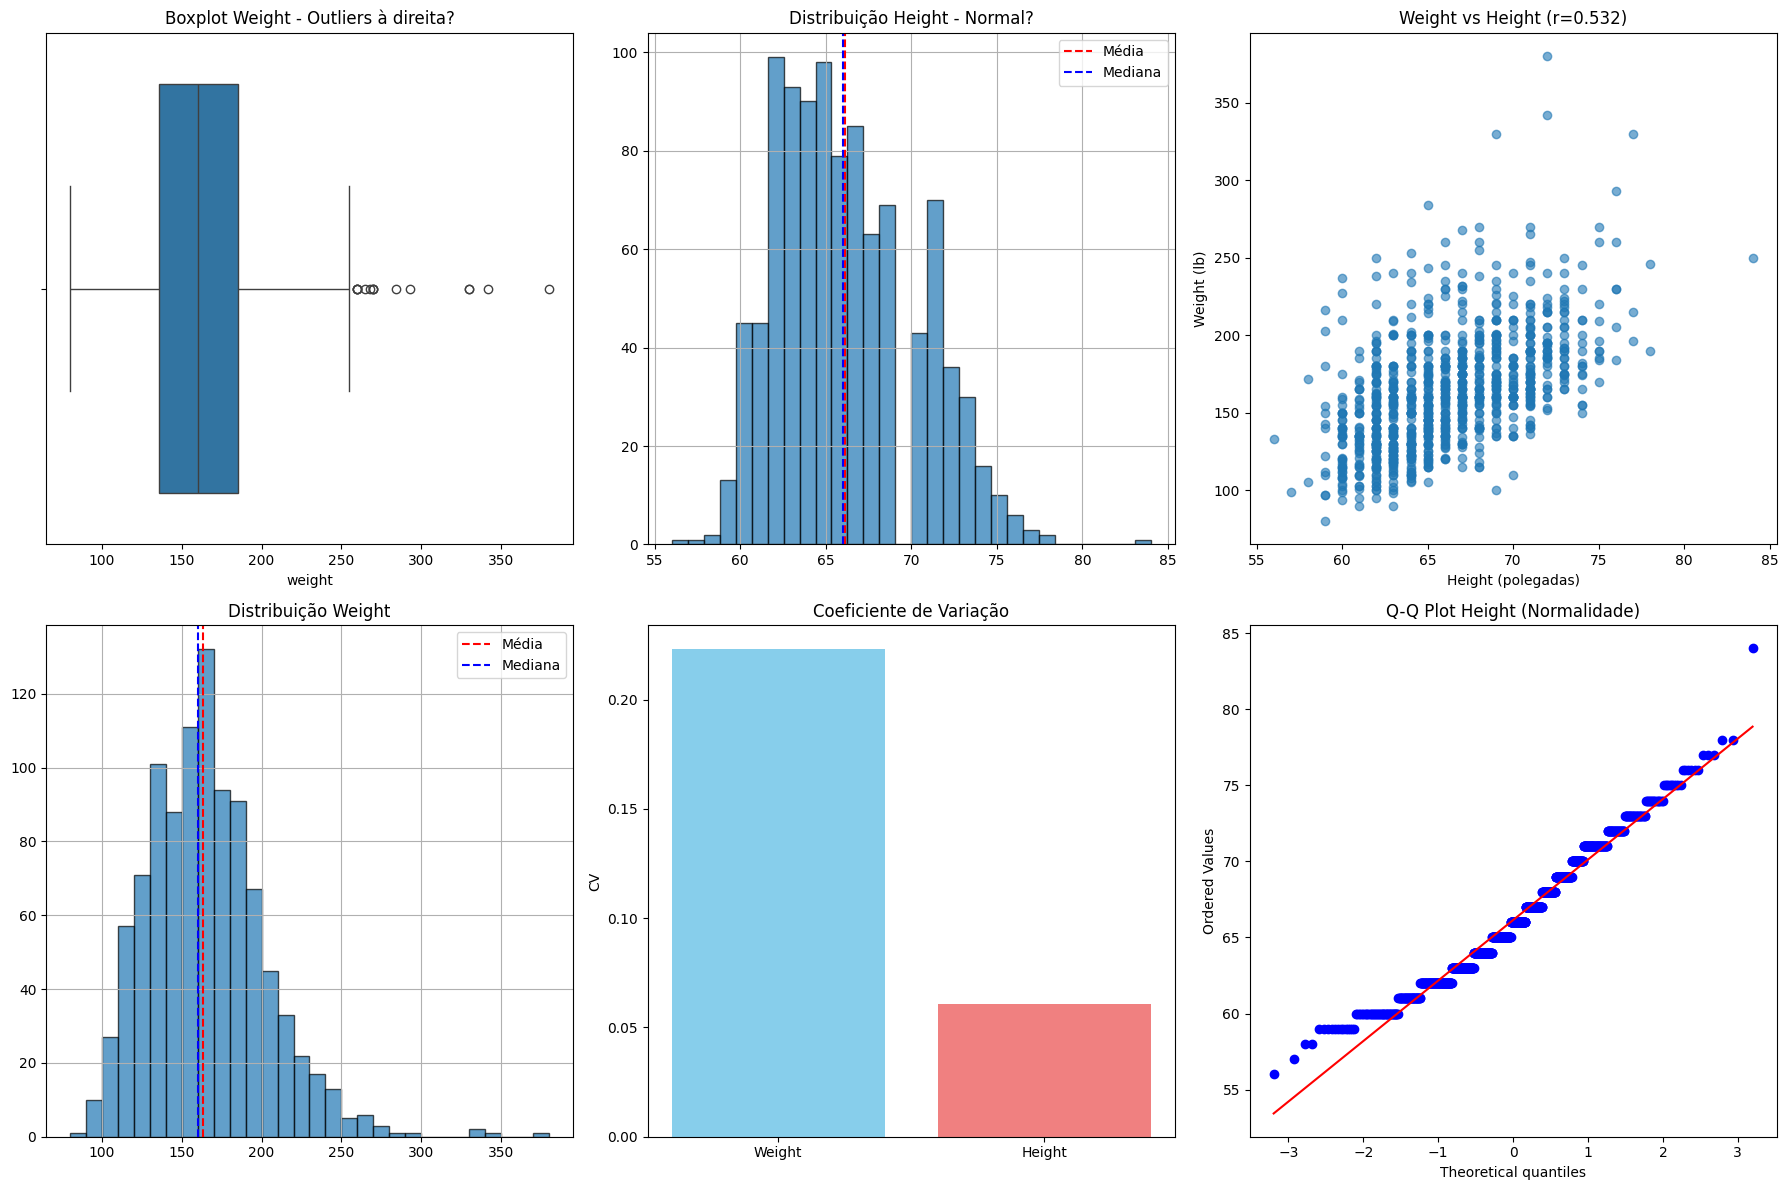

In [18]:
# Visualizações para confirmar as análises
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Boxplot do weight (outliers à direita)
sns.boxplot(x=df['weight'], ax=axes[0,0])
axes[0,0].set_title('Boxplot Weight - Outliers à direita?')

# 2. Histograma da altura (normalidade)
df['height'].hist(bins=30, ax=axes[0,1], alpha=0.7, edgecolor='black')
axes[0,1].set_title('Distribuição Height - Normal?')
axes[0,1].axvline(df['height'].mean(), color='red', linestyle='--', label='Média')
axes[0,1].axvline(df['height'].median(), color='blue', linestyle='--', label='Mediana')
axes[0,1].legend()

# 3. Scatter plot Weight vs Height (correlação)
axes[0,2].scatter(df['height'], df['weight'], alpha=0.6)
axes[0,2].set_xlabel('Height (polegadas)')
axes[0,2].set_ylabel('Weight (lb)')
axes[0,2].set_title(f'Weight vs Height (r={correlation:.3f})')

# 4. Histograma do weight (assimetria)
df['weight'].hist(bins=30, ax=axes[1,0], alpha=0.7, edgecolor='black')
axes[1,0].set_title('Distribuição Weight')
axes[1,0].axvline(df['weight'].mean(), color='red', linestyle='--', label='Média')
axes[1,0].axvline(df['weight'].median(), color='blue', linestyle='--', label='Mediana')
axes[1,0].legend()

# 5. Comparação dos CVs
cv_data = ['Weight', 'Height']
cv_values = [cv_weight, cv_height]
axes[1,1].bar(cv_data, cv_values, color=['skyblue', 'lightcoral'])
axes[1,1].set_title('Coeficiente de Variação')
axes[1,1].set_ylabel('CV')

# 6. Q-Q plot para normalidade da altura
from scipy import stats
stats.probplot(df['height'], dist="norm", plot=axes[1,2])
axes[1,2].set_title('Q-Q Plot Height (Normalidade)')

plt.tight_layout()
plt.show()

In [19]:
# Análise de outliers detalhada
print("=== ANÁLISE DE OUTLIERS (WEIGHT) ===")
Q1 = df['weight'].quantile(0.25)
Q3 = df['weight'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['weight'] < lower_bound) | (df['weight'] > upper_bound)]
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Limite superior: {upper_bound:.2f}")
print(f"Outliers encontrados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Valores extremos à direita: {len(df[df['weight'] > upper_bound])}")

=== ANÁLISE DE OUTLIERS (WEIGHT) ===
Q1: 136.00, Q3: 185.00, IQR: 49.00
Limite superior: 258.50
Outliers encontrados: 15 (1.5%)
Valores extremos à direita: 15
